#  Dataset Preprocessing 

In [1]:
import numpy as np 
from tqdm import tqdm
import cv2
import os
import imutils


In [2]:
def crop_img(img):
	"""
	Finds the extreme points on the image and crops the rectangular out of them
	"""
	gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
	gray = cv2.GaussianBlur(gray, (3, 3), 0)

	# threshold the image, then perform a series of erosions +
	# dilations to remove any small regions of noise
	thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
	thresh = cv2.erode(thresh, None, iterations=2)
	thresh = cv2.dilate(thresh, None, iterations=2)

	# find contours in thresholded image, then grab the largest one
	cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
	cnts = imutils.grab_contours(cnts)
	c = max(cnts, key=cv2.contourArea)

	# find the extreme points
	extLeft = tuple(c[c[:, :, 0].argmin()][0])
	extRight = tuple(c[c[:, :, 0].argmax()][0])
	extTop = tuple(c[c[:, :, 1].argmin()][0])
	extBot = tuple(c[c[:, :, 1].argmax()][0])
	ADD_PIXELS = 0
	new_img = img[extTop[1]-ADD_PIXELS:extBot[1]+ADD_PIXELS, extLeft[0]-ADD_PIXELS:extRight[0]+ADD_PIXELS].copy()
	
	return new_img
	
if __name__ == "__main__":
	training = "tumor/Training"
	testing = 'tumor/Testing'
	training_dir = os.listdir('tumor/Training')
	testing_dir = os.listdir('tumor/Testing')
	IMG_SIZE = 256

	for dir in training_dir:
		save_path = 'cleaned/Training/'+ dir
		path = os.path.join(training,dir)
		image_dir = os.listdir(path)
		for img in image_dir:
			image = cv2.imread(os.path.join(path,img))
			new_img = crop_img(image)
			new_img = cv2.resize(new_img,(IMG_SIZE,IMG_SIZE))
			if not os.path.exists(save_path):
				os.makedirs(save_path)
			cv2.imwrite(save_path+'/'+img, new_img)
	
	for dir in testing_dir:
		save_path = 'cleaned/Testing/'+ dir
		path = os.path.join(testing,dir)
		image_dir = os.listdir(path)
		for img in image_dir:
			image = cv2.imread(os.path.join(path,img))
			new_img = crop_img(image)
			new_img = cv2.resize(new_img,(IMG_SIZE,IMG_SIZE))
			if not os.path.exists(save_path):
				os.makedirs(save_path)
			cv2.imwrite(save_path+'/'+img, new_img)

In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.initializers import HeUniform, GlorotUniform
from sklearn.preprocessing import StandardScaler
import numpy as npa
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import os
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix , accuracy_score
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import GlobalAveragePooling2D, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import losses
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [9]:
import pathlib

train_dir = 'tumor/Training'
test_dir = 'tumor/Testing'



# Data Preprocessing with ImageDataGenerator

In [12]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Defining Train & Test Folders

In [13]:
train_dir = str( "tumor/Training") 
test_dir = str( "tumor/Testing")  

# Define Image Size & Batch Size for Model

In [14]:
batch_size = 32
img_height = 240
img_width = 240

# Loading Training and Test Datasets

In [15]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (img_height , img_width),
    batch_size= batch_size,
    class_mode = "categorical"
    )

test_generator = test_datagen.flow_from_directory(
    train_dir,
    target_size = (img_height , img_width),
    batch_size = batch_size,
    class_mode = "categorical"

    )

print(r"Class Label :" , train_generator.class_indices)


Found 5712 images belonging to 4 classes.
Found 5712 images belonging to 4 classes.
Class Label : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


#  VISUALIZATION

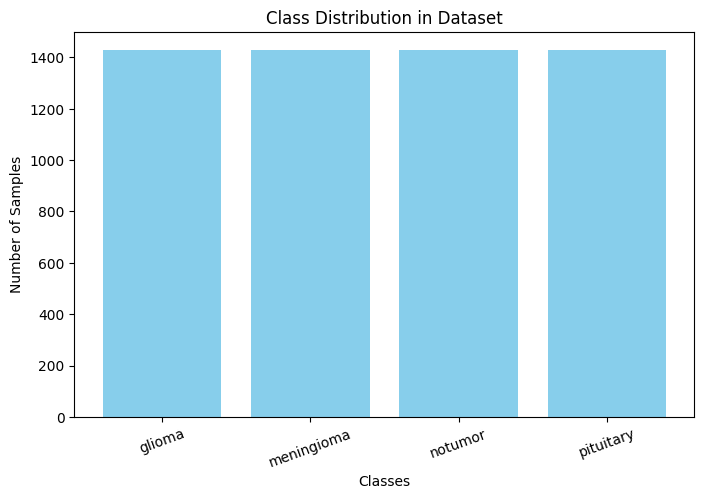

In [16]:
import matplotlib.pyplot as plt

class_labels = list(train_generator.class_indices.keys())
class_counts = [len(train_generator.filepaths) // train_generator.num_classes] * len(class_labels)

plt.figure(figsize=(8, 5))
plt.bar(class_labels, class_counts, color='skyblue')
plt.xlabel("Classes")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in Dataset")
plt.xticks(rotation=20)
plt.show()

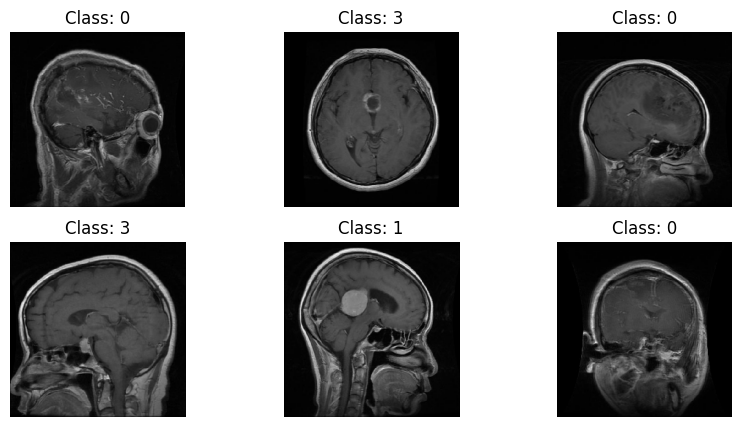

In [17]:
import numpy as np
import matplotlib.pyplot as plt

x_batch, y_batch = next(train_generator)  

plt.figure(figsize=(10, 5))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(x_batch[i])
    plt.title(f"Class: {np.argmax(y_batch[i])}") 
    plt.axis("off")
plt.show()

# DEVELOP THE MODEL

In [18]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,          
    width_shift_range=0.2,     
    height_shift_range=0.2,    
    shear_range=0.2,           
    zoom_range=0.2,             
    horizontal_flip=True,       
    fill_mode='nearest'       
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [19]:
model = Sequential([
    Conv2D(32 , (5,5) , activation="relu" ,padding="valid", kernel_initializer=HeUniform()),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Conv2D(64 , (5,5) , activation="relu" ,padding="valid", kernel_initializer=HeUniform()),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Conv2D(128 , (5,5) , activation="relu" ,padding="valid", kernel_initializer=HeUniform()),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Flatten(),

    Dense(64 , activation="relu" , kernel_initializer=HeUniform()),
    Dropout(0.2),
    BatchNormalization(),
    Dense(128 , activation="relu" , kernel_initializer=HeUniform()),
    Dropout(0.2),
    BatchNormalization(),
    Dense(256 , activation="relu" , kernel_initializer=HeUniform()),
    Dropout(0.3),
    BatchNormalization(),

    Dense(4 , activation="softmax" , kernel_initializer=GlorotUniform()),

    ])



In [20]:
model.compile(optimizer=Adam(learning_rate=0.0001) , loss="categorical_crossentropy", metrics=["accuracy"])

In [22]:
early_stop = EarlyStopping(patience=3,monitor="val_loss", restore_best_weights=True)

fit = model.fit(train_generator,epochs=10 #(epoch count is reduced due to process length.)
, validation_data=(test_generator) , callbacks=[early_stop])

C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 611s 3s/step - accuracy: 0.5736 - loss: 1.0854 - val_accuracy: 0.7181 - val_loss: 0.7522
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 587s 3s/step - accuracy: 0.7679 - loss: 0.6316 - val_accuracy: 0.8093 - val_loss: 0.4886
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 597s 3s/step - accuracy: 0.8311 - loss: 0.4784 - val_accuracy: 0.8922 - val_loss: 0.3017
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 479s 3s/step - accuracy: 0.8756 - loss: 0.3364 - val_accuracy: 0.9552 - val_loss: 0.1388
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 395s 2s/step - accuracy: 0.9114 - loss: 0.2310 - val_accuracy: 0.9688 - val_loss: 0.1125
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 424s 2s/step - accuracy: 0.9305 - loss: 0.2020 - val_accuracy: 0.9809 - val_loss: 0.0637
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 394s 2s/step - accuracy: 0.9458 - loss: 0.1536 - val_accuracy: 0.9953 - val_loss: 0.0307
Epoch 8/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 376s 2s/step - accuracy: 0.9656 - loss: 0.1107 - val_accu